# GemiCenterSingle Non-Sweeping (32↔64 Transfer)

Fixed, simple setup for learning neural transfer operators both ways:
- up: `omega=32 -> 64`
- down: `omega=64 -> 32`

No hyperparameter sweeps, no dataset-size sweeps.


## Why these defaults

These are educated defaults aimed at learnability with manageable cost:
- uses your unified PML constants: `npml=104`, `eta=70.0`, `pml_power=2.0`.
- `n_tot=500` gives `n_phys=292`, matching your earlier unified geometry scale.
- fixed split sizes: `n_train=240`, `n_val=60`, `n_test=60`.
- training/validation/testing are done on interior only (`non`-PML window).


In [3]:
import os
import random
from dataclasses import dataclass

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


In [4]:
@dataclass
class RunCfg:
    # Geometry / physics
    n_tot: int = 500
    npml: int = 104
    omega_low: float = 32.0
    omega_high: float = 64.0
    pml_eta: float = 70.0
    pml_power: float = 2.0

    # Source family: centered point source with jitter
    source_center_jitter: int = 10
    source_amp_min: float = 0.8
    source_amp_max: float = 1.2

    # Train/eval only on non-PML interior
    train_on_interior_only: bool = True

    # Data splits (requested)
    n_train: int = 240
    n_val: int = 60
    n_test: int = 60

    # Training (fixed; non-sweeping)
    width: int = 40
    epochs: int = 120
    batch_size: int = 12
    lr: float = 1e-3
    weight_decay: float = 1e-6
    seed: int = 20260220

cfg = RunCfg()
print(cfg)
print("n_phys:", cfg.n_tot - 2 * cfg.npml)

if cfg.n_tot <= 2 * cfg.npml:
    raise ValueError("n_tot must be > 2*npml for non-PML interior training.")


RunCfg(n_tot=500, npml=104, omega_low=32.0, omega_high=64.0, pml_eta=70.0, pml_power=2.0, source_center_jitter=10, source_amp_min=0.8, source_amp_max=1.2, train_on_interior_only=True, n_train=240, n_val=60, n_test=60, width=40, epochs=120, batch_size=12, lr=0.001, weight_decay=1e-06, seed=20260220)
n_phys: 292


In [5]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(cfg.seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cpu


/math/home/fkiewiet/Freq2Transfer/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [6]:
def sigma_profile_1d(n_tot: int, n_pml: int, eta: float, pml_power: float) -> np.ndarray:
    sig = np.zeros(n_tot, dtype=float)
    if n_pml <= 0:
        return sig
    for i in range(n_tot):
        if i < n_pml:
            dist = (n_pml - i) / n_pml
        elif i >= n_tot - n_pml:
            dist = (i - (n_tot - n_pml) + 1) / n_pml
        else:
            dist = 0.0
        sig[i] = eta * (dist ** pml_power)
    return sig


def get_helmholtz_matrix(omega: float, n_tot: int, n_pml: int, eta: float, pml_power: float) -> sp.csr_matrix:
    h = 1.0 / (n_tot - 1)
    k2 = float(omega) * float(omega)

    sig = sigma_profile_1d(n_tot, n_pml, eta, pml_power)
    s = 1.0 / (1.0 + 1j * sig / (omega / (2.0 * np.pi)))

    rows, cols, vals = [], [], []

    def lin(i, j):
        return i * n_tot + j

    def add(r, c, v):
        rows.append(r); cols.append(c); vals.append(v)

    for i in range(n_tot):
        sx = s[i]
        for j in range(n_tot):
            idx = lin(i, j)

            # Dirichlet on outer boundary
            if i == 0 or j == 0 or i == n_tot - 1 or j == n_tot - 1:
                add(idx, idx, 1.0 + 0.0j)
                continue

            sy = s[j]
            c0 = -2.0 * (sx * sx + sy * sy) / (h * h) + k2
            add(idx, idx, c0)

            add(idx, lin(i - 1, j), sx * sx / (h * h))
            add(idx, lin(i + 1, j), sx * sx / (h * h))
            add(idx, lin(i, j - 1), sy * sy / (h * h))
            add(idx, lin(i, j + 1), sy * sy / (h * h))

    return sp.coo_matrix((vals, (rows, cols)), shape=(n_tot * n_tot, n_tot * n_tot)).tocsr()


def make_centered_source_rhs(cfg_local: RunCfg, rng_local: np.random.Generator):
    n = cfg_local.n_tot
    f = np.zeros((n, n), dtype=np.complex128)

    c = n // 2
    jtr = int(cfg_local.source_center_jitter)
    i = int(np.clip(c + rng_local.integers(-jtr, jtr + 1), cfg_local.npml + 2, n - cfg_local.npml - 3))
    j = int(np.clip(c + rng_local.integers(-jtr, jtr + 1), cfg_local.npml + 2, n - cfg_local.npml - 3))

    amp = rng_local.uniform(cfg_local.source_amp_min, cfg_local.source_amp_max)
    ph = rng_local.uniform(0.0, 2.0 * np.pi)
    f[i, j] = amp * np.exp(1j * ph)
    return f, (i, j)


def to_2ch(arr: np.ndarray) -> np.ndarray:
    return np.stack([arr.real, arr.imag], axis=0).astype(np.float32)


def from_2ch(arr2: np.ndarray) -> np.ndarray:
    return arr2[0].astype(np.float64) + 1j * arr2[1].astype(np.float64)


In [7]:
print("Assembling matrices...")
A32 = get_helmholtz_matrix(cfg.omega_low, cfg.n_tot, cfg.npml, cfg.pml_eta, cfg.pml_power)
A64 = get_helmholtz_matrix(cfg.omega_high, cfg.n_tot, cfg.npml, cfg.pml_eta, cfg.pml_power)

print("Factorizing matrices (this may take a bit)...")
solve32 = spla.factorized(A32.tocsc())
solve64 = spla.factorized(A64.tocsc())

print("A32 shape:", A32.shape, "nnz:", A32.nnz)
print("A64 shape:", A64.shape, "nnz:", A64.nnz)


Assembling matrices...
Factorizing matrices (this may take a bit)...
A32 shape: (250000, 250000) nnz: 1242016
A64 shape: (250000, 250000) nnz: 1242016


In [9]:
def solve_field_with(solver, f2d: np.ndarray, n_tot: int) -> np.ndarray:
    u = solver(f2d.reshape(-1))
    return u.reshape(n_tot, n_tot)


def build_split(n_samples: int, seed: int, cfg_local: RunCfg):
    rng = np.random.default_rng(seed)

    X_up, Y_up = [], []
    X_dn, Y_dn = [], []
    F_all = []
    IJ = []

    for _ in range(n_samples):
        f, ij = make_centered_source_rhs(cfg_local, rng)
        u32 = solve_field_with(solve32, f, cfg_local.n_tot)
        u64 = solve_field_with(solve64, f, cfg_local.n_tot)

        X_up.append(to_2ch(u32)); Y_up.append(to_2ch(u64))
        X_dn.append(to_2ch(u64)); Y_dn.append(to_2ch(u32))
        F_all.append(to_2ch(f))
        IJ.append(ij)

    return {
        "X_up": np.asarray(X_up, dtype=np.float32),
        "Y_up": np.asarray(Y_up, dtype=np.float32),
        "X_down": np.asarray(X_dn, dtype=np.float32),
        "Y_down": np.asarray(Y_dn, dtype=np.float32),
        "F": np.asarray(F_all, dtype=np.float32),
        "src_ij": np.asarray(IJ, dtype=np.int32),
    }

In [ ]:


print("Building datasets...")
train = build_split(cfg.n_train, cfg.seed + 1, cfg)
val = build_split(cfg.n_val, cfg.seed + 2, cfg)
test = build_split(cfg.n_test, cfg.seed + 3, cfg)

print("train:", train["X_up"].shape, train["Y_up"].shape)
print("val:  ", val["X_up"].shape, val["Y_up"].shape)
print("test: ", test["X_up"].shape, test["Y_up"].shape)


Building datasets...
train: (240, 2, 500, 500) (240, 2, 500, 500)
val:   (60, 2, 500, 500) (60, 2, 500, 500)
test:  (60, 2, 500, 500) (60, 2, 500, 500)


In [18]:
def window_nonpml(X: np.ndarray, npml: int) -> np.ndarray:
    if npml <= 0:
        return X
    return X[:, :, npml:-npml, npml:-npml]


def scale_fit(X: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    s = X.std(axis=(0, 2, 3)).astype(np.float32)
    return np.maximum(s, eps)


def scale_apply(X: np.ndarray, s: np.ndarray) -> np.ndarray:
    return X / s[None, :, None, None]


def scale_undo(X: np.ndarray, s: np.ndarray) -> np.ndarray:
    return X * s[None, :, None, None]


def rel_l2(pred: np.ndarray, true: np.ndarray) -> np.ndarray:
    num = np.sqrt(np.sum((pred - true) ** 2, axis=(1, 2, 3)))
    den = np.sqrt(np.sum((true) ** 2, axis=(1, 2, 3))) + 1e-12
    return num / den


In [10]:
class PlainCNN(nn.Module):
    def __init__(self, width: int = 40):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, width, 3, padding=1), nn.GELU(),
            nn.Conv2d(width, width, 3, padding=1), nn.GELU(),
            nn.Conv2d(width, width, 3, padding=1), nn.GELU(),
            nn.Conv2d(width, width, 3, padding=1), nn.GELU(),
            nn.Conv2d(width, width, 3, padding=1), nn.GELU(),
            nn.Conv2d(width, 2, 3, padding=1),
        )

    def forward(self, x):
        return self.net(x)


def make_loader(X: np.ndarray, Y: np.ndarray, batch_size: int, shuffle: bool):
    ds = torch.utils.data.TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(Y, dtype=torch.float32),
    )
    return torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)


def train_one_direction(Xtr, Ytr, Xva, Yva, cfg_local: RunCfg):
    model = PlainCNN(width=cfg_local.width).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg_local.lr, weight_decay=cfg_local.weight_decay)

    tr_loader = make_loader(Xtr, Ytr, cfg_local.batch_size, shuffle=True)
    va_loader = make_loader(Xva, Yva, cfg_local.batch_size, shuffle=False)

    best_state = None
    best_val = float("inf")
    history = []

    for ep in range(1, cfg_local.epochs + 1):
        model.train()
        tr_loss = 0.0
        ntr = 0
        for xb, yb in tr_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            opt.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = F.mse_loss(pred, yb)
            loss.backward()
            opt.step()
            tr_loss += loss.item() * xb.shape[0]
            ntr += xb.shape[0]

        model.eval()
        va_loss = 0.0
        nva = 0
        with torch.no_grad():
            for xb, yb in va_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                pred = model(xb)
                loss = F.mse_loss(pred, yb)
                va_loss += loss.item() * xb.shape[0]
                nva += xb.shape[0]

        tr_mse = tr_loss / max(ntr, 1)
        va_mse = va_loss / max(nva, 1)

        if va_mse < best_val:
            best_val = va_mse
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        history.append((ep, tr_mse, va_mse))
        if ep == 1 or ep % 20 == 0 or ep == cfg_local.epochs:
            print(f"epoch {ep:03d} | train_mse={tr_mse:.3e} | val_mse={va_mse:.3e}")

    model.load_state_dict(best_state)
    return model, history, best_val


def predict_np(model: nn.Module, X: np.ndarray, batch_size: int = 16) -> np.ndarray:
    model.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i+batch_size], dtype=torch.float32, device=device)
            yb = model(xb).detach().cpu().numpy()
            out.append(yb)
    return np.concatenate(out, axis=0)


In [11]:
def train_direction(direction: str, cfg_local: RunCfg):
    if direction == "up":
        Xtr_full, Ytr_full = train["X_up"], train["Y_up"]
        Xva_full, Yva_full = val["X_up"], val["Y_up"]
        Xte_full, Yte_full = test["X_up"], test["Y_up"]
        label = "32->64"
    else:
        Xtr_full, Ytr_full = train["X_down"], train["Y_down"]
        Xva_full, Yva_full = val["X_down"], val["Y_down"]
        Xte_full, Yte_full = test["X_down"], test["Y_down"]
        label = "64->32"

    if not cfg_local.train_on_interior_only:
        raise ValueError("This notebook is configured for interior-only (non-PML) training.")

    Xtr = window_nonpml(Xtr_full, cfg_local.npml)
    Ytr = window_nonpml(Ytr_full, cfg_local.npml)
    Xva = window_nonpml(Xva_full, cfg_local.npml)
    Yva = window_nonpml(Yva_full, cfg_local.npml)
    Xte = window_nonpml(Xte_full, cfg_local.npml)
    Yte = window_nonpml(Yte_full, cfg_local.npml)

    print(f"Using interior-only window: {Xtr.shape[-2]}x{Xtr.shape[-1]} (npml={cfg_local.npml})")

    sx = scale_fit(Xtr)
    sy = scale_fit(Ytr)

    Xtr_n = scale_apply(Xtr, sx)
    Ytr_n = scale_apply(Ytr, sy)
    Xva_n = scale_apply(Xva, sx)
    Yva_n = scale_apply(Yva, sy)
    Xte_n = scale_apply(Xte, sx)

    print(f"\nTraining {label}")
    model, hist, best_val = train_one_direction(Xtr_n, Ytr_n, Xva_n, Yva_n, cfg_local)

    pred_te_n = predict_np(model, Xte_n, batch_size=cfg_local.batch_size)
    pred_te = scale_undo(pred_te_n, sy)

    id_rel = rel_l2(Xte, Yte)
    pred_rel = rel_l2(pred_te, Yte)

    summary = {
        "direction": direction,
        "label": label,
        "best_val_mse": float(best_val),
        "identity_rel_l2_mean": float(id_rel.mean()),
        "pred_rel_l2_mean": float(pred_rel.mean()),
        "improvement_factor_mean": float((id_rel / np.maximum(pred_rel, 1e-12)).mean()),
        "pred_rel_l2_median": float(np.median(pred_rel)),
    }

    return {
        "model": model,
        "history": hist,
        "summary": summary,
        "pred_test_phys": pred_te,
        "true_test_phys": Yte,
        "init_test_phys": Xte,
        "scales": {"sx": sx, "sy": sy},
    }

res_up = train_direction("up", cfg)
res_dn = train_direction("down", cfg)

print("\n=== Test Summary ===")
for r in (res_up, res_dn):
    s = r["summary"]
    print(
        f"{s['label']}: val_mse={s['best_val_mse']:.3e}, "
        f"id_relL2={s['identity_rel_l2_mean']:.3e}, pred_relL2={s['pred_rel_l2_mean']:.3e}, "
        f"improve_x={s['improvement_factor_mean']:.2f}"
    )


Using interior-only window: 292x292 (npml=104)

Training 32->64
epoch 001 | train_mse=9.703e-01 | val_mse=9.451e-01
epoch 020 | train_mse=8.165e-01 | val_mse=8.197e-01
epoch 040 | train_mse=8.079e-01 | val_mse=8.063e-01
epoch 060 | train_mse=8.027e-01 | val_mse=8.077e-01
epoch 080 | train_mse=7.903e-01 | val_mse=8.010e-01
epoch 100 | train_mse=7.504e-01 | val_mse=7.538e-01
epoch 120 | train_mse=6.814e-01 | val_mse=6.862e-01
Using interior-only window: 292x292 (npml=104)

Training 64->32
epoch 001 | train_mse=9.547e-01 | val_mse=9.202e-01
epoch 020 | train_mse=6.580e-01 | val_mse=6.431e-01
epoch 040 | train_mse=6.480e-01 | val_mse=6.444e-01
epoch 060 | train_mse=7.098e-01 | val_mse=6.657e-01
epoch 080 | train_mse=6.443e-01 | val_mse=6.367e-01
epoch 100 | train_mse=6.355e-01 | val_mse=6.373e-01
epoch 120 | train_mse=6.381e-01 | val_mse=6.493e-01

=== Test Summary ===
32->64: val_mse=6.862e-01, id_relL2=1.928e+00, pred_relL2=8.350e-01, improve_x=2.32
64->32: val_mse=6.284e-01, id_relL2=1.

In [12]:
def inject_phys_into_full(u_full_2ch: np.ndarray, u_phys_2ch: np.ndarray, npml: int) -> np.ndarray:
    out = u_full_2ch.copy()
    out[:, npml:-npml, npml:-npml] = u_phys_2ch
    return out


def residual_ratio(A: sp.csr_matrix, u2_full: np.ndarray, f2_full: np.ndarray) -> float:
    u = from_2ch(u2_full)
    f = from_2ch(f2_full)
    r = f.reshape(-1) - A @ u.reshape(-1)
    return float(np.linalg.norm(r) / (np.linalg.norm(f) + 1e-12))

# quick residual check on first 10 test examples
n_chk = min(10, cfg.n_test)
res_rows = []
for k in range(n_chk):
    # up direction: target operator is A64
    init_up_full = test["X_up"][k]
    pred_up_full = inject_phys_into_full(init_up_full, res_up["pred_test_phys"][k], cfg.npml)
    rr_init_up = residual_ratio(A64, init_up_full, test["F"][k])
    rr_pred_up = residual_ratio(A64, pred_up_full, test["F"][k])

    # down direction: target operator is A32
    init_dn_full = test["X_down"][k]
    pred_dn_full = inject_phys_into_full(init_dn_full, res_dn["pred_test_phys"][k], cfg.npml)
    rr_init_dn = residual_ratio(A32, init_dn_full, test["F"][k])
    rr_pred_dn = residual_ratio(A32, pred_dn_full, test["F"][k])

    res_rows.append((rr_init_up, rr_pred_up, rr_init_dn, rr_pred_dn))

res_rows = np.array(res_rows)
print("Residual ratio (lower is better) over first", n_chk, "test samples")
print("up   init mean:", res_rows[:,0].mean(), "pred mean:", res_rows[:,1].mean())
print("down init mean:", res_rows[:,2].mean(), "pred mean:", res_rows[:,3].mean())


Residual ratio (lower is better) over first 10 test samples
up   init mean: 0.3854111695275676 pred mean: 5.481950420021461
down init mean: 0.2350025932594661 pred mean: 2.7800004421745017


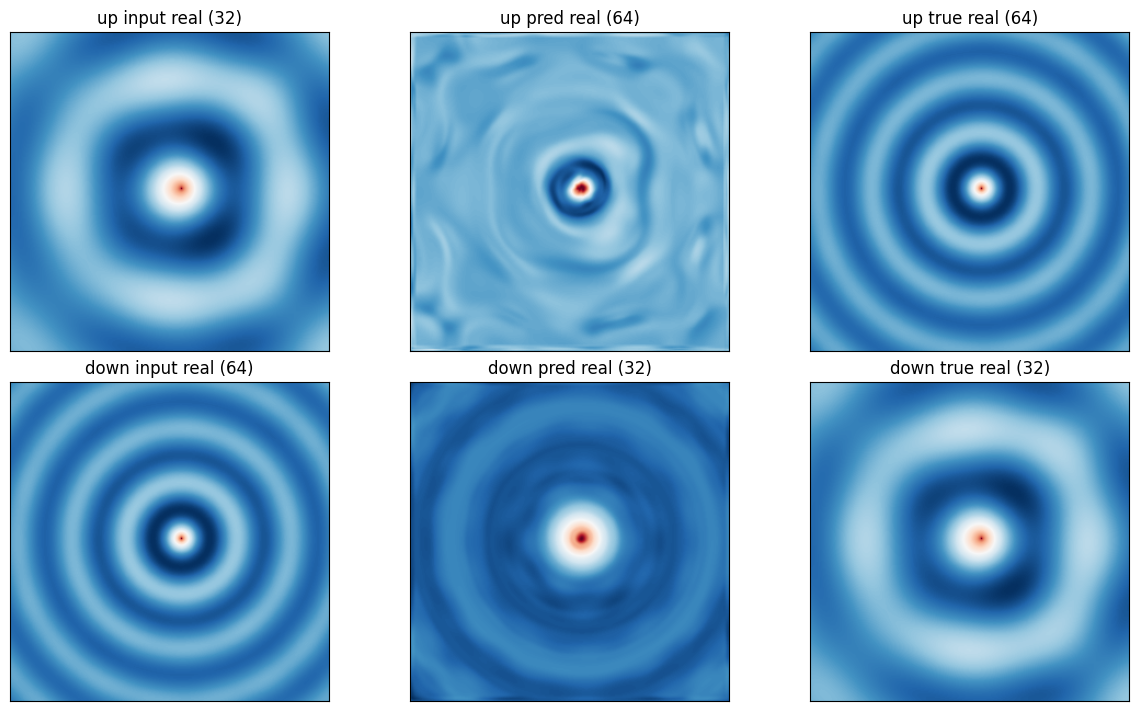

In [13]:
# Visualize one sample in each direction (physical window only)
idx = 0
fig, axs = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)

axs[0,0].imshow(res_up["init_test_phys"][idx,0], cmap="RdBu_r")
axs[0,0].set_title("up input real (32)")
axs[0,1].imshow(res_up["pred_test_phys"][idx,0], cmap="RdBu_r")
axs[0,1].set_title("up pred real (64)")
axs[0,2].imshow(res_up["true_test_phys"][idx,0], cmap="RdBu_r")
axs[0,2].set_title("up true real (64)")

axs[1,0].imshow(res_dn["init_test_phys"][idx,0], cmap="RdBu_r")
axs[1,0].set_title("down input real (64)")
axs[1,1].imshow(res_dn["pred_test_phys"][idx,0], cmap="RdBu_r")
axs[1,1].set_title("down pred real (32)")
axs[1,2].imshow(res_dn["true_test_phys"][idx,0], cmap="RdBu_r")
axs[1,2].set_title("down true real (32)")

for ax in axs.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.show()


In [14]:
# Save trained operators
os.makedirs("experiments/checkpoints", exist_ok=True)

torch.save({
    "state_dict": res_up["model"].state_dict(),
    "cfg": cfg.__dict__,
    "summary": res_up["summary"],
    "direction": "up",
}, "experiments/checkpoints/cnn_nonsweep_32_64_up.pth")

torch.save({
    "state_dict": res_dn["model"].state_dict(),
    "cfg": cfg.__dict__,
    "summary": res_dn["summary"],
    "direction": "down",
}, "experiments/checkpoints/cnn_nonsweep_64_32_down.pth")

print("saved:")
print("- experiments/checkpoints/cnn_nonsweep_32_64_up.pth")
print("- experiments/checkpoints/cnn_nonsweep_64_32_down.pth")


saved:
- experiments/checkpoints/cnn_nonsweep_32_64_up.pth
- experiments/checkpoints/cnn_nonsweep_64_32_down.pth


## ASSESS

In [2]:
# 1) Re-import + config (must match training setup)
import os
import random
from dataclasses import dataclass
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import torch
import torch.nn as nn
import torch.nn.functional as F

@dataclass
class RunCfg:
    n_tot: int = 500
    npml: int = 104
    omega_low: float = 32.0
    omega_high: float = 64.0
    pml_eta: float = 70.0
    pml_power: float = 2.0
    source_center_jitter: int = 10
    source_amp_min: float = 0.8
    source_amp_max: float = 1.2
    train_on_interior_only: bool = True
    n_train: int = 240
    n_val: int = 60
    n_test: int = 60
    width: int = 40
    epochs: int = 120
    batch_size: int = 12
    lr: float = 1e-3
    weight_decay: float = 1e-6
    seed: int = 20260220

cfg = RunCfg()
device = "cuda" if torch.cuda.is_available() else "cpu"


/math/home/fkiewiet/Freq2Transfer/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
# 2) Re-define model class exactly as before
class PlainCNN(nn.Module):
    def __init__(self, width: int = 40):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, width, 3, padding=1), nn.GELU(),
            nn.Conv2d(width, width, 3, padding=1), nn.GELU(),
            nn.Conv2d(width, width, 3, padding=1), nn.GELU(),
            nn.Conv2d(width, width, 3, padding=1), nn.GELU(),
            nn.Conv2d(width, width, 3, padding=1), nn.GELU(),
            nn.Conv2d(width, 2, 3, padding=1),
        )
    def forward(self, x):
        return self.net(x)


In [4]:
# 3) Load trained checkpoints
ckpt_up = torch.load("experiments/checkpoints/cnn_nonsweep_32_64_up.pth", map_location=device)
ckpt_dn = torch.load("experiments/checkpoints/cnn_nonsweep_64_32_down.pth", map_location=device)

model_up = PlainCNN(width=ckpt_up["cfg"]["width"]).to(device)
model_dn = PlainCNN(width=ckpt_dn["cfg"]["width"]).to(device)

model_up.load_state_dict(ckpt_up["state_dict"])
model_dn.load_state_dict(ckpt_dn["state_dict"])
model_up.eval(); model_dn.eval()

print("Loaded:", ckpt_up["direction"], ckpt_dn["direction"])
print("Up summary:", ckpt_up.get("summary", {}))
print("Down summary:", ckpt_dn.get("summary", {}))


Loaded: up down
Up summary: {'direction': 'up', 'label': '32->64', 'best_val_mse': 0.6862239837646484, 'identity_rel_l2_mean': 1.9284424781799316, 'pred_rel_l2_mean': 0.8350096344947815, 'improvement_factor_mean': 2.320615291595459, 'pred_rel_l2_median': 0.8184293508529663}
Down summary: {'direction': 'down', 'label': '64->32', 'best_val_mse': 0.6284037470817566, 'identity_rel_l2_mean': 1.2112847566604614, 'pred_rel_l2_mean': 0.8053367733955383, 'improvement_factor_mean': 1.5430736541748047, 'pred_rel_l2_median': 0.7704569101333618}


In [10]:
# 4) Rebuild datasets deterministically (same seed => same splits)
# Re-run your existing cells that define:
# - sigma_profile_1d, get_helmholtz_matrix
# - make_centered_source_rhs, solve_field_with, build_split
# Then:
A32 = get_helmholtz_matrix(cfg.omega_low, cfg.n_tot, cfg.npml, cfg.pml_eta, cfg.pml_power)
A64 = get_helmholtz_matrix(cfg.omega_high, cfg.n_tot, cfg.npml, cfg.pml_eta, cfg.pml_power)
solve32 = spla.factorized(A32.tocsc())
solve64 = spla.factorized(A64.tocsc())

train = build_split(cfg.n_train, cfg.seed + 1, cfg)
val   = build_split(cfg.n_val,   cfg.seed + 2, cfg)
test  = build_split(cfg.n_test,  cfg.seed + 3, cfg)

print(train["X_up"].shape, val["X_up"].shape, test["X_up"].shape)


(240, 2, 500, 500) (60, 2, 500, 500) (60, 2, 500, 500)


## trial2

In [15]:
import torch
import numpy as np

ckpt_up_path = "experiments/checkpoints/cnn_nonsweep_32_64_up.pth"
ckpt_dn_path = "experiments/checkpoints/cnn_nonsweep_64_32_down.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_up = torch.load(ckpt_up_path, map_location=device)
ckpt_dn = torch.load(ckpt_dn_path, map_location=device)

print("Loaded:", ckpt_up_path, "direction =", ckpt_up.get("direction"))
print("Loaded:", ckpt_dn_path, "direction =", ckpt_dn.get("direction"))

Loaded: experiments/checkpoints/cnn_nonsweep_32_64_up.pth direction = up
Loaded: experiments/checkpoints/cnn_nonsweep_64_32_down.pth direction = down


In [16]:
def torch_predict_np(model, X_np, batch_size=16, device=None):
    """
    X_np: (N, 2, H, W) float/complex split into 2 channels
    returns: (N, 2, H, W) numpy float32
    """
    if device is None:
        device = next(model.parameters()).device

    preds = []
    N = X_np.shape[0]
    with torch.no_grad():
        for i in range(0, N, batch_size):
            xb = torch.from_numpy(X_np[i:i+batch_size]).to(device)
            yb = model(xb)
            preds.append(yb.detach().cpu().numpy())
    return np.concatenate(preds, axis=0)

In [19]:
# Build interior-only test tensors (same as training)
Xte_up = window_nonpml(test["X_up"], cfg.npml)
Yte_up = window_nonpml(test["Y_up"], cfg.npml)

Xte_dn = window_nonpml(test["X_down"], cfg.npml)
Yte_dn = window_nonpml(test["Y_down"], cfg.npml)

# If you used scaling in training, you MUST reload it too.
# But your checkpoint does NOT contain scales, so:
# - either your training didn't actually scale, or
# - you saved scales elsewhere, or
# - your "scale_fit/apply/undo" are identity.
#
# If scaling is identity, you're fine.
# If scaling is nontrivial, you need the saved scales to match training.

## Check

In [22]:
# ---- Rebuild res_up / res_dn using loaded models ----

def torch_predict_np(model, X_np, batch_size=16):
    model.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            xb = torch.tensor(X_np[i:i+batch_size], dtype=torch.float32, device=device)
            yb = model(xb).cpu().numpy()
            out.append(yb)
    return np.concatenate(out, axis=0)

# Interior-only window (same as training)
Xte_up = window_nonpml(test["X_up"], cfg.npml)
Yte_up = window_nonpml(test["Y_up"], cfg.npml)

Xte_dn = window_nonpml(test["X_down"], cfg.npml)
Yte_dn = window_nonpml(test["Y_down"], cfg.npml)

# IMPORTANT: recompute scaling exactly like training did
sx_up = scale_fit(window_nonpml(train["X_up"], cfg.npml))
sy_up = scale_fit(window_nonpml(train["Y_up"], cfg.npml))

sx_dn = scale_fit(window_nonpml(train["X_down"], cfg.npml))
sy_dn = scale_fit(window_nonpml(train["Y_down"], cfg.npml))

# Normalize test inputs
Xte_up_n = scale_apply(Xte_up, sx_up)
Xte_dn_n = scale_apply(Xte_dn, sx_dn)

# Predict
pred_up_n = torch_predict_np(model_up, Xte_up_n, batch_size=cfg.batch_size)
pred_dn_n = torch_predict_np(model_dn, Xte_dn_n, batch_size=cfg.batch_size)

# Undo scaling
pred_up = scale_undo(pred_up_n, sy_up)
pred_dn = scale_undo(pred_dn_n, sy_dn)

# Recreate result dicts exactly like training returned
res_up = {
    "pred_test_phys": pred_up,
    "true_test_phys": Yte_up,
    "init_test_phys": Xte_up,
}

res_dn = {
    "pred_test_phys": pred_dn,
    "true_test_phys": Yte_dn,
    "init_test_phys": Xte_dn,
}

print("Rebuilt res_up and res_dn from checkpoints.")

Rebuilt res_up and res_dn from checkpoints.


In [23]:
# Cell 1 — Build per-sample diagnostics table

import numpy as np
import pandas as pd

# ---- helpers ----
def _to_complex(x2):
    """(2,H,W) or (N,2,H,W) -> complex array"""
    return x2[..., 0, :, :].astype(np.float64) + 1j * x2[..., 1, :, :].astype(np.float64)

def _rel_l2(pred, true):
    num = np.sqrt(np.sum((pred - true) ** 2, axis=(1, 2, 3)))
    den = np.sqrt(np.sum(true ** 2, axis=(1, 2, 3))) + 1e-12
    return num / den

def _inject_interior(u_full_2ch, u_phys_2ch, npml):
    u = u_full_2ch.copy()
    u[:, npml:-npml, npml:-npml] = u_phys_2ch
    return u

def _residual_ratio(A, u_full_2ch, f_full_2ch):
    u = _to_complex(u_full_2ch).reshape(-1)
    f = _to_complex(f_full_2ch).reshape(-1)
    r = f - A @ u
    return float(np.linalg.norm(r) / (np.linalg.norm(f) + 1e-12))

def _phase_mae(pred2, true2):
    p = _to_complex(pred2)
    t = _to_complex(true2)
    dphi = np.angle(np.exp(1j * (np.angle(p) - np.angle(t))))  # wrapped phase diff
    return float(np.mean(np.abs(dphi)))

def _complex_corr(pred2, true2):
    p = _to_complex(pred2).reshape(-1)
    t = _to_complex(true2).reshape(-1)
    return float(np.abs(np.vdot(t, p)) / (np.linalg.norm(t) * np.linalg.norm(p) + 1e-12))

# ---- main loop ----
rows = []
center = cfg.n_tot // 2

specs = [
    ("up_32_to_64",   res_up, A64, "X_up",   "Y_up"),
    ("down_64_to_32", res_dn, A32, "X_down", "Y_down"),
]

for direction, res_obj, A_target, X_key, Y_key in specs:
    pred_phys = res_obj["pred_test_phys"]
    true_phys = res_obj["true_test_phys"]
    init_phys = res_obj["init_test_phys"]

    rel_pred = _rel_l2(pred_phys, true_phys)
    rel_init = _rel_l2(init_phys, true_phys)

    for k in range(len(pred_phys)):
        init_full = test[X_key][k]
        pred_full = _inject_interior(init_full, pred_phys[k], cfg.npml)
        f_full = test["F"][k]

        rr_init = _residual_ratio(A_target, init_full, f_full)
        rr_pred = _residual_ratio(A_target, pred_full, f_full)

        src_i, src_j = test["src_ij"][k]
        src_r = float(np.hypot(src_i - center, src_j - center))

        rows.append({
            "direction": direction,
            "sample": k,
            "src_i": int(src_i),
            "src_j": int(src_j),
            "src_r_from_center": src_r,
            "rel_l2_init": float(rel_init[k]),
            "rel_l2_pred": float(rel_pred[k]),
            "improve_rel_l2_x": float(rel_init[k] / max(rel_pred[k], 1e-12)),
            "res_ratio_init": rr_init,
            "res_ratio_pred": rr_pred,
            "improve_residual_x": float(rr_init / max(rr_pred, 1e-12)),
            "phase_mae_init_rad": _phase_mae(init_phys[k], true_phys[k]),
            "phase_mae_pred_rad": _phase_mae(pred_phys[k], true_phys[k]),
            "complex_corr_init": _complex_corr(init_phys[k], true_phys[k]),
            "complex_corr_pred": _complex_corr(pred_phys[k], true_phys[k]),
        })

diag_df = pd.DataFrame(rows)
diag_df.head()

,direction,sample,src_i,src_j,src_r_from_center,rel_l2_init,rel_l2_pred,improve_rel_l2_x,res_ratio_init,res_ratio_pred,improve_residual_x,phase_mae_init_rad,phase_mae_pred_rad,complex_corr_init,complex_corr_pred
0,up_32_to_64,0,247,260,10.440307,1.902128,0.866976,2.193981,0.378210,5.126911,0.073770,1.657230,1.102613,0.138072,0.564391
1,up_32_to_64,1,241,258,12.041595,1.886721,0.988091,1.909461,0.374553,5.227070,0.071656,1.656327,1.485716,0.134307,0.440438
2,up_32_to_64,2,250,248,2.000000,1.961324,0.790390,2.481463,0.393404,5.834243,0.067430,1.657749,1.116438,0.153135,0.641926
3,up_32_to_64,3,245,260,11.180340,1.894828,0.975817,1.941787,0.376437,4.932582,0.076316,1.656955,1.347783,0.136275,0.423062
4,up_32_to_64,4,255,252,5.385165,1.942000,0.770714,2.519741,0.388459,5.577951,0.069642,1.656450,0.933069,0.148117,0.641274


In [24]:
# Cell 2 — Compact summary stats (mean/median/p90/failure rates)

def p90(x): return np.percentile(x, 90)

summary = (
    diag_df.groupby("direction")
    .agg(
        n=("sample", "count"),
        rel_l2_init_mean=("rel_l2_init", "mean"),
        rel_l2_pred_mean=("rel_l2_pred", "mean"),
        rel_l2_pred_median=("rel_l2_pred", "median"),
        rel_l2_pred_p90=("rel_l2_pred", p90),
        improve_rel_l2_mean=("improve_rel_l2_x", "mean"),
        improve_rel_l2_median=("improve_rel_l2_x", "median"),
        improve_residual_mean=("improve_residual_x", "mean"),
        improve_residual_median=("improve_residual_x", "median"),
        fail_rel_l2_rate=("improve_rel_l2_x", lambda x: float(np.mean(x <= 1.0))),
        fail_residual_rate=("improve_residual_x", lambda x: float(np.mean(x <= 1.0))),
    )
    .reset_index()
)
summary


,direction,n,rel_l2_init_mean,rel_l2_pred_mean,rel_l2_pred_median,rel_l2_pred_p90,improve_rel_l2_mean,improve_rel_l2_median,improve_residual_mean,improve_residual_median,fail_rel_l2_rate,fail_residual_rate
0,down_64_to_32,60,1.211285,0.805337,0.770457,1.010458,1.543074,1.570831,0.083861,0.082527,0.0,1.0
1,up_32_to_64,60,1.928443,0.835010,0.818429,0.928467,2.320616,2.353385,0.069881,0.069525,0.0,1.0


In [27]:
torch.save({
    "state_dict": res_up["model"].state_dict(),
    "cfg": cfg.__dict__,
    "summary": res_up["summary"],
    "direction": "up",
    "history": res_up["history"],
    "scales": res_up["scales"],
}, "experiments/checkpoints/cnn_nonsweep_32_64_up.pth")

KeyError: 'model'

(sidetrack start)

In [28]:
import pandas as pd

rows = []
for name, ckpt in [("up_32_to_64", ckpt_up), ("down_64_to_32", ckpt_dn)]:
    s = ckpt["summary"]
    rows.append({
        "direction": name,
        "best_val_mse": s["best_val_mse"],
        "relL2_identity_mean": s["identity_rel_l2_mean"],
        "relL2_pred_mean": s["pred_rel_l2_mean"],
        "improvement_mean_x": s["improvement_factor_mean"],
        "relL2_pred_median": s["pred_rel_l2_median"],
    })

pd.DataFrame(rows)

,direction,best_val_mse,relL2_identity_mean,relL2_pred_mean,improvement_mean_x,relL2_pred_median
0,up_32_to_64,0.686224,1.928442,0.835010,2.320615,0.818429
1,down_64_to_32,0.628404,1.211285,0.805337,1.543074,0.770457


In [29]:
import numpy as np
import matplotlib.pyplot as plt

def plot_learning_curves(label, hist):
    arr = np.asarray(hist, dtype=float)
    ep, tr, va = arr[:, 0], arr[:, 1], arr[:, 2]
    gap = va - tr

    fig, ax = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    ax[0].plot(ep, tr, label="train_mse")
    ax[0].plot(ep, va, label="val_mse")
    ax[0].set_yscale("log")
    ax[0].set_title(label)
    ax[0].set_xlabel("epoch")
    ax[0].legend()

    ax[1].plot(ep, gap)
    ax[1].axhline(0.0, color="k", lw=1)
    ax[1].set_title(f"{label} val − train gap")
    ax[1].set_xlabel("epoch")
    plt.show()

for label, res_obj in [("up_32_to_64", res_up), ("down_64_to_32", res_dn)]:
    hist = res_obj.get("history")
    if hist is None:
        print(f"[skip] {label}: no training history saved in checkpoint (only summary available).")
        continue
    plot_learning_curves(label, hist)

[skip] up_32_to_64: no training history saved in checkpoint (only summary available).
[skip] down_64_to_32: no training history saved in checkpoint (only summary available).


In [30]:
print(ckpt_up.keys())
print(ckpt_dn.keys())

dict_keys(['state_dict', 'cfg', 'summary', 'direction'])
dict_keys(['state_dict', 'cfg', 'summary', 'direction'])


(sidetrack end)

In [26]:
# Cell 3 — Learning curves and validation gap

import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curves(label, history):
    """
    history: list of (epoch, train_mse, val_mse)
    """
    arr = np.asarray(history)
    epochs = arr[:, 0]
    train_mse = arr[:, 1]
    val_mse = arr[:, 2]
    gap = val_mse - train_mse

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

    # --- MSE curves ---
    axes[0].plot(epochs, train_mse, label="train MSE")
    axes[0].plot(epochs, val_mse, label="val MSE")
    axes[0].set_yscale("log")
    axes[0].set_title(f"{label} — learning curves")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("MSE (log scale)")
    axes[0].legend()

    # --- Overfitting gap ---
    axes[1].plot(epochs, gap)
    axes[1].axhline(0.0, color="k", lw=1)
    axes[1].set_title(f"{label} — validation gap (val − train)")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("MSE gap")

    plt.show()


for label, hist in [
    ("up_32_to_64", res_up["history"]),
    ("down_64_to_32", res_dn["history"]),
]:
    plot_learning_curves(label, hist)

KeyError: 'history'

In [ ]:
# Cell 4 — Identity vs prediction scatter (target: points below diagonal)

fig, axs = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

for ax, direction in zip(axs, ["up_32_to_64", "down_64_to_32"]):
    d = diag_df[diag_df["direction"] == direction]
    ax.scatter(d["rel_l2_init"], d["rel_l2_pred"], alpha=0.7)
    lo = min(d["rel_l2_init"].min(), d["rel_l2_pred"].min())
    hi = max(d["rel_l2_init"].max(), d["rel_l2_pred"].max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_xlabel("identity rel-L2")
    ax.set_ylabel("pred rel-L2")
    ax.set_title(direction)

plt.show()


In [ ]:
# Cell 5 — Distribution plots: improvement factor and residual improvement

fig, axs = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)

for r, direction in enumerate(["up_32_to_64", "down_64_to_32"]):
    d = diag_df[diag_df["direction"] == direction]

    axs[r, 0].hist(d["improve_rel_l2_x"], bins=20)
    axs[r, 0].axvline(1.0, color="r", ls="--")
    axs[r, 0].set_title(f"{direction} improvement rel-L2 (x)")
    axs[r, 0].set_xlabel("identity / pred")

    axs[r, 1].hist(d["improve_residual_x"], bins=20)
    axs[r, 1].axvline(1.0, color="r", ls="--")
    axs[r, 1].set_title(f"{direction} improvement residual (x)")
    axs[r, 1].set_xlabel("identity / pred")

plt.show()


NameError: name 'plt' is not defined

In [ ]:
# Cell 6 — CDF of improvement (robust view)

def plot_cdf(ax, x, label):
    xs = np.sort(np.asarray(x))
    ys = np.arange(1, len(xs) + 1) / len(xs)
    ax.plot(xs, ys, label=label)

fig, axs = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

for ax, direction in zip(axs, ["up_32_to_64", "down_64_to_32"]):
    d = diag_df[diag_df["direction"] == direction]
    plot_cdf(ax, d["improve_rel_l2_x"], "rel-L2 improvement")
    plot_cdf(ax, d["improve_residual_x"], "residual improvement")
    ax.axvline(1.0, color="k", ls="--", lw=1)
    ax.set_title(direction)
    ax.set_xlabel("improvement factor (identity/pred)")
    ax.set_ylabel("CDF")
    ax.legend()

plt.show()


In [ ]:
# Cell 7 — Source-location dependence (does model fail near some regions?)

for direction in ["up_32_to_64", "down_64_to_32"]:
    d = diag_df[diag_df["direction"] == direction]
    pivot = d.pivot_table(index="src_i", columns="src_j", values="improve_rel_l2_x", aggfunc="mean")

    plt.figure(figsize=(5, 4))
    plt.imshow(pivot.values, origin="lower", aspect="auto")
    plt.colorbar(label="mean improve rel-L2 (x)")
    plt.title(f"{direction}: source-location map")
    plt.xlabel("src_j bins (unique)")
    plt.ylabel("src_i bins (unique)")
    plt.show()


In [ ]:
# Cell 8 — Improvement vs source radius from center

fig, axs = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

for ax, direction in zip(axs, ["up_32_to_64", "down_64_to_32"]):
    d = diag_df[diag_df["direction"] == direction]
    ax.scatter(d["src_r_from_center"], d["improve_rel_l2_x"], alpha=0.7)
    ax.axhline(1.0, color="k", ls="--", lw=1)
    ax.set_title(direction)
    ax.set_xlabel("source radius from center")
    ax.set_ylabel("improve rel-L2 (x)")

plt.show()


In [ ]:
# Cell 9 — Phase-error diagnostics

fig, axs = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

for ax, direction in zip(axs, ["up_32_to_64", "down_64_to_32"]):
    d = diag_df[diag_df["direction"] == direction]
    ax.hist(d["phase_mae_init_rad"], bins=20, alpha=0.5, label="identity")
    ax.hist(d["phase_mae_pred_rad"], bins=20, alpha=0.5, label="pred")
    ax.set_title(direction)
    ax.set_xlabel("phase MAE (rad)")
    ax.legend()

plt.show()


In [ ]:
# Cell 10 — Complex-correlation diagnostics

fig, axs = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

for ax, direction in zip(axs, ["up_32_to_64", "down_64_to_32"]):
    d = diag_df[diag_df["direction"] == direction]
    ax.hist(d["complex_corr_init"], bins=20, alpha=0.5, label="identity")
    ax.hist(d["complex_corr_pred"], bins=20, alpha=0.5, label="pred")
    ax.set_title(direction)
    ax.set_xlabel("|<u_true,u_pred>|/(||u_true||||u_pred||)")
    ax.legend()

plt.show()


In [ ]:
# Cell 11 — Spectral error profile (radial average) init vs pred

def radial_spectrum(err2):
    z = _from_2ch(err2)
    F = np.fft.fftshift(np.fft.fft2(z))
    A = np.abs(F)

    nx, ny = A.shape
    cx, cy = nx // 2, ny // 2
    yy, xx = np.indices(A.shape)
    rr = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2).astype(int)

    maxr = rr.max()
    out = np.zeros(maxr + 1, dtype=np.float64)
    cnt = np.zeros(maxr + 1, dtype=np.float64)
    for r in range(maxr + 1):
        m = (rr == r)
        out[r] = A[m].mean() if np.any(m) else 0.0
        cnt[r] = m.sum()
    return out

for direction, res_obj in [("up_32_to_64", res_up), ("down_64_to_32", res_dn)]:
    init_err = res_obj["init_test_phys"] - res_obj["true_test_phys"]
    pred_err = res_obj["pred_test_phys"] - res_obj["true_test_phys"]

    s_init = np.mean([radial_spectrum(e) for e in init_err], axis=0)
    s_pred = np.mean([radial_spectrum(e) for e in pred_err], axis=0)

    n = min(len(s_init), len(s_pred))
    r = np.arange(n)

    plt.figure(figsize=(6, 4))
    plt.plot(r, np.log10(s_init[:n] + 1e-12), label="identity error spectrum")
    plt.plot(r, np.log10(s_pred[:n] + 1e-12), label="pred error spectrum")
    plt.title(direction)
    plt.xlabel("radial frequency bin")
    plt.ylabel("log10 amplitude")
    plt.legend()
    plt.show()


In [ ]:
# Cell 12 — Worst and best cases visualization (fast triage)

def show_case(direction, idx, title_prefix=""):
    res_obj = res_up if direction == "up_32_to_64" else res_dn
    init2 = res_obj["init_test_phys"][idx]
    pred2 = res_obj["pred_test_phys"][idx]
    true2 = res_obj["true_test_phys"][idx]

    err_init = np.linalg.norm(init2 - true2)
    err_pred = np.linalg.norm(pred2 - true2)

    fig, axs = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
    axs[0,0].imshow(init2[0], cmap="RdBu_r"); axs[0,0].set_title("init real")
    axs[0,1].imshow(pred2[0], cmap="RdBu_r"); axs[0,1].set_title("pred real")
    axs[0,2].imshow(true2[0], cmap="RdBu_r"); axs[0,2].set_title("true real")
    axs[1,0].imshow((init2-true2)[0], cmap="RdBu_r"); axs[1,0].set_title("init error real")
    axs[1,1].imshow((pred2-true2)[0], cmap="RdBu_r"); axs[1,1].set_title("pred error real")
    axs[1,2].axis("off")
    fig.suptitle(f"{title_prefix}{direction} | idx={idx} | ||init-true||={err_init:.3e}, ||pred-true||={err_pred:.3e}")
    plt.show()

for direction in ["up_32_to_64", "down_64_to_32"]:
    d = diag_df[diag_df["direction"] == direction].copy()
    worst_idx = int(d.sort_values("improve_rel_l2_x").iloc[0]["sample"])
    best_idx  = int(d.sort_values("improve_rel_l2_x").iloc[-1]["sample"])
    show_case(direction, worst_idx, "WORST ")
    show_case(direction, best_idx, "BEST ")


In [ ]:
# Cell 13 — Failure table (where to improve first)

fail_df = diag_df[
    (diag_df["improve_rel_l2_x"] <= 1.0) | (diag_df["improve_residual_x"] <= 1.0)
].copy()

fail_df = fail_df.sort_values(["direction", "improve_rel_l2_x", "improve_residual_x"])
print(f"Failing samples: {len(fail_df)} / {len(diag_df)}")
fail_df.head(30)


In [ ]:
# Cell 14 — Correlation matrix (what correlates with failure)

cols = [
    "rel_l2_init", "rel_l2_pred", "improve_rel_l2_x",
    "res_ratio_init", "res_ratio_pred", "improve_residual_x",
    "phase_mae_init_rad", "phase_mae_pred_rad",
    "complex_corr_init", "complex_corr_pred",
    "src_r_from_center"
]
for direction in ["up_32_to_64", "down_64_to_32"]:
    c = diag_df[diag_df["direction"] == direction][cols].corr(numeric_only=True)
    plt.figure(figsize=(8, 6))
    plt.imshow(c.values, vmin=-1, vmax=1)
    plt.colorbar(label="corr")
    plt.xticks(range(len(cols)), cols, rotation=90)
    plt.yticks(range(len(cols)), cols)
    plt.title(f"{direction} correlation matrix")
    plt.tight_layout()
    plt.show()


In [ ]:
# Cell 15 — Bootstrap confidence intervals for improvement means

def bootstrap_mean_ci(x, n_boot=3000, alpha=0.05, seed=0):
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    n = len(x)
    means = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        means[b] = x[idx].mean()
    lo = np.percentile(means, 100 * (alpha / 2))
    hi = np.percentile(means, 100 * (1 - alpha / 2))
    return x.mean(), lo, hi

for direction in ["up_32_to_64", "down_64_to_32"]:
    d = diag_df[diag_df["direction"] == direction]
    m1, l1, h1 = bootstrap_mean_ci(d["improve_rel_l2_x"].values, seed=1)
    m2, l2, h2 = bootstrap_mean_ci(d["improve_residual_x"].values, seed=2)
    print(direction)
    print(f"  improve_rel_l2_x mean={m1:.3f}, 95% CI=({l1:.3f}, {h1:.3f})")
    print(f"  improve_residual_x mean={m2:.3f}, 95% CI=({l2:.3f}, {h2:.3f})")


In [ ]:
# Cell 16 — Auto-generated diagnosis hints from metrics

for direction in ["up_32_to_64", "down_64_to_32"]:
    d = diag_df[diag_df["direction"] == direction]
    fail_rel = float(np.mean(d["improve_rel_l2_x"] <= 1.0))
    fail_res = float(np.mean(d["improve_residual_x"] <= 1.0))
    p90_rel = float(np.percentile(d["rel_l2_pred"], 90))
    med_imp = float(np.median(d["improve_rel_l2_x"]))

    print(f"\n{direction}")
    print(f"- median improve rel-L2: {med_imp:.3f}x")
    print(f"- failure rate rel-L2: {100*fail_rel:.1f}%")
    print(f"- failure rate residual: {100*fail_res:.1f}%")
    print(f"- p90 pred rel-L2: {p90_rel:.3e}")

    if med_imp < 1.2:
        print("  Suggestion: increase model capacity or train longer; current gain is modest.")
    if fail_rel > 0.2:
        print("  Suggestion: investigate failure clusters by source location/radius and add targeted samples.")
    if fail_res > 0.2:
        print("  Suggestion: consider physics-aware loss term (residual penalty) in addition to MSE.")
    if p90_rel > 2.0 * float(np.median(d['rel_l2_pred'])):
        print("  Suggestion: heavy-tail errors; robust loss (Huber) may improve outliers.")
